# 06 — Severe Rainfall Target Definition

This notebook evaluates the precipitation distribution observed at the Recife automatic weather station (WMO A301) during the effective modeling period.

The objective is to define a defensible hourly precipitation threshold for the severe-rainfall classification target.

The analysis considers:

- precipitation data availability;
- dry and rainy hour frequencies;
- precipitation percentiles;
- candidate intensity thresholds;
- contiguous exceedance events;
- yearly distribution of intense rainfall observations;
- class imbalance produced by each candidate threshold.

No missing precipitation observations are treated as zero.

=== MODELING PERIOD ===

Start: 2018-01-01 00:00:00+00:00
End: 2021-11-12 06:00:00+00:00
Total hourly timestamps: 33871

=== PRECIPITATION AVAILABILITY ===

Total timestamps: 33871
Hours with precipitation measurement: 33302
Hours without precipitation measurement: 569
Precipitation availability: 98.32%

Dry hours: 28777
Rainy hours: 4525
Rainy-hour percentage: 13.59%

=== PRECIPITATION STATISTICS ===


,precipitation_mm
count,33302.000000
mean,0.225386
std,1.248546
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,45.600000



Maximum hourly precipitation: 45.6 mm
Maximum precipitation timestamp: 2021-04-11 23:00:00+00:00

=== PRECIPITATION PERCENTILES ===


,all_valid_hours_mm,rainy_hours_only_mm
90%,0.2,4.0000
95%,1.0,6.4000
97.5%,2.4,9.8000
99%,5.0,15.2000
99.5%,7.6,20.4760
99.9%,18.4,28.3616



=== CANDIDATE THRESHOLD ANALYSIS ===


,threshold_mm_h,positive_hours,positive_pct,negative_hours,negative_to_positive_ratio,contiguous_events
0,1,1832,5.501,31470,17.178,1078
1,2,1062,3.189,32240,30.358,701
2,5,338,1.015,32964,97.527,241
3,10,109,0.327,33193,304.523,87
4,15,49,0.147,33253,678.633,38
5,20,24,0.072,33278,1386.583,22
6,25,11,0.033,33291,3026.455,11
7,30,4,0.012,33298,8324.500,4



=== POSITIVE HOURS BY YEAR ===


year,2018,2019,2020,2021
threshold_mm_h,,,,
1,365,515,411,541
2,218,293,236,315
5,67,95,74,102
10,17,32,22,38
15,9,15,9,16
20,5,6,5,8
25,2,3,3,3
30,0,1,2,1



=== TOP 25 HOURLY PRECIPITATION OBSERVATIONS ===


,precipitation_mm
datetime_utc,
2021-04-11 23:00:00+00:00,45.6
2020-03-16 02:00:00+00:00,41.8
2019-03-31 13:00:00+00:00,31.6
2020-04-26 05:00:00+00:00,30.4
2018-04-06 21:00:00+00:00,29.2
2018-02-20 14:00:00+00:00,27.6
2019-02-06 04:00:00+00:00,27.0
2020-04-24 13:00:00+00:00,25.6
2021-03-01 12:00:00+00:00,25.6


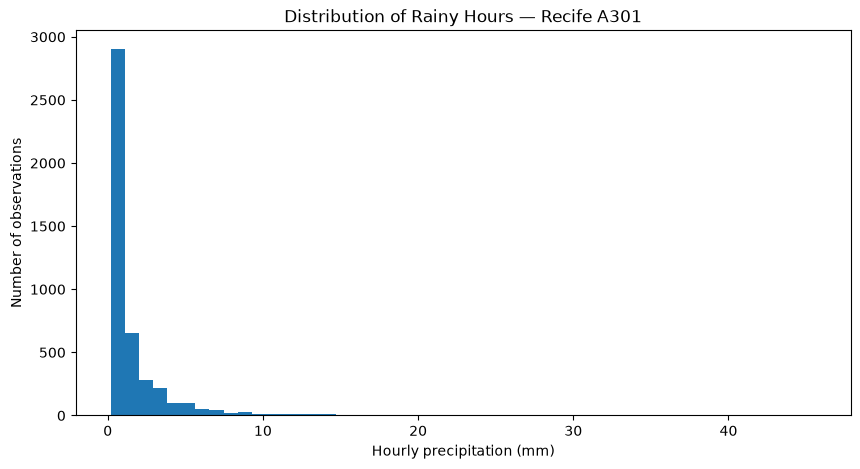

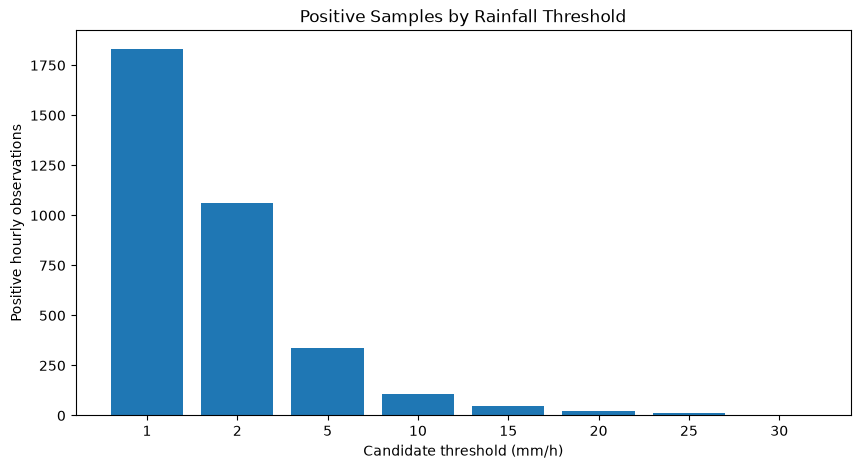

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. CONFIGURATION
# ============================================================

INPUT_PATH = Path(
    "../data/processed/recife_2018_2023_hourly.csv"
)

MODEL_START = pd.Timestamp(
    "2018-01-01 00:00",
    tz="UTC"
)

MODEL_END = pd.Timestamp(
    "2021-11-12 06:00",
    tz="UTC"
)

CANDIDATE_THRESHOLDS = [
    1,
    2,
    5,
    10,
    15,
    20,
    25,
    30,
]


# ============================================================
# 2. LOAD DATASET
# ============================================================

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["datetime_utc"],
)


df = (
    df
    .set_index("datetime_utc")
    .sort_index()
)


df = df.loc[
    MODEL_START:MODEL_END
].copy()


df["precipitation_mm"] = pd.to_numeric(
    df["precipitation_mm"],
    errors="coerce",
)


print("=== MODELING PERIOD ===")
print()

print(
    "Start:",
    df.index.min()
)

print(
    "End:",
    df.index.max()
)

print(
    "Total hourly timestamps:",
    len(df)
)


# ============================================================
# 3. PRECIPITATION AVAILABILITY
# ============================================================

precipitation = df["precipitation_mm"]

valid_precipitation = (
    precipitation.dropna()
)

rainy_precipitation = (
    valid_precipitation[
        valid_precipitation > 0
    ]
)


total_hours = len(df)

available_hours = len(
    valid_precipitation
)

missing_hours = (
    total_hours
    - available_hours
)

dry_hours = int(
    (valid_precipitation == 0).sum()
)

rainy_hours = int(
    (valid_precipitation > 0).sum()
)


print()
print(
    "=== PRECIPITATION AVAILABILITY ==="
)
print()

print(
    "Total timestamps:",
    total_hours
)

print(
    "Hours with precipitation measurement:",
    available_hours
)

print(
    "Hours without precipitation measurement:",
    missing_hours
)

print(
    "Precipitation availability:",
    f"{available_hours / total_hours * 100:.2f}%"
)

print()

print(
    "Dry hours:",
    dry_hours
)

print(
    "Rainy hours:",
    rainy_hours
)

print(
    "Rainy-hour percentage:",
    f"{rainy_hours / available_hours * 100:.2f}%"
)


# ============================================================
# 4. PRECIPITATION DESCRIPTIVE STATISTICS
# ============================================================

print()
print(
    "=== PRECIPITATION STATISTICS ==="
)

display(
    valid_precipitation
    .describe()
    .to_frame(
        "precipitation_mm"
    )
)


maximum_precipitation = (
    valid_precipitation.max()
)

maximum_timestamp = (
    valid_precipitation.idxmax()
)


print()
print(
    "Maximum hourly precipitation:",
    maximum_precipitation,
    "mm"
)

print(
    "Maximum precipitation timestamp:",
    maximum_timestamp
)


# ============================================================
# 5. PRECIPITATION PERCENTILES
# ============================================================

percentiles = [
    0.90,
    0.95,
    0.975,
    0.99,
    0.995,
    0.999,
]


all_hour_percentiles = (
    valid_precipitation.quantile(
        percentiles
    )
)


rainy_hour_percentiles = (
    rainy_precipitation.quantile(
        percentiles
    )
)


percentile_df = pd.DataFrame(
    {
        "all_valid_hours_mm":
            all_hour_percentiles,

        "rainy_hours_only_mm":
            rainy_hour_percentiles,
    }
)


percentile_df.index = [
    f"{percentile * 100:g}%"
    for percentile in percentiles
]


print()
print(
    "=== PRECIPITATION PERCENTILES ==="
)

display(
    percentile_df
)


# ============================================================
# 6. CANDIDATE THRESHOLD ANALYSIS
# ============================================================

threshold_results = []


for threshold in CANDIDATE_THRESHOLDS:

    exceedance = (
        valid_precipitation
        >= threshold
    )

    positive_hours = int(
        exceedance.sum()
    )

    negative_hours = (
        available_hours
        - positive_hours
    )

    positive_percentage = (
        positive_hours
        / available_hours
        * 100
    )

    negative_to_positive_ratio = (
        negative_hours / positive_hours
        if positive_hours > 0
        else np.inf
    )


    # --------------------------------------------------------
    # Count contiguous threshold-exceedance episodes
    # --------------------------------------------------------

    full_exceedance = (
        precipitation.notna()
        &
        (
            precipitation
            >= threshold
        )
    )

    event_starts = (
        full_exceedance
        &
        ~full_exceedance.shift(
            1,
            fill_value=False,
        )
    )

    contiguous_events = int(
        event_starts.sum()
    )


    threshold_results.append(
        {
            "threshold_mm_h":
                threshold,

            "positive_hours":
                positive_hours,

            "positive_pct":
                positive_percentage,

            "negative_hours":
                negative_hours,

            "negative_to_positive_ratio":
                negative_to_positive_ratio,

            "contiguous_events":
                contiguous_events,
        }
    )


threshold_df = pd.DataFrame(
    threshold_results
)


print()
print(
    "=== CANDIDATE THRESHOLD ANALYSIS ==="
)

display(
    threshold_df.round(3)
)


# ============================================================
# 7. YEARLY DISTRIBUTION FOR EACH THRESHOLD
# ============================================================

yearly_results = []


for year in sorted(
    df.index.year.unique()
):

    year_precipitation = (
        precipitation[
            df.index.year == year
        ]
        .dropna()
    )

    for threshold in CANDIDATE_THRESHOLDS:

        positive_hours = int(
            (
                year_precipitation
                >= threshold
            )
            .sum()
        )


        yearly_results.append(
            {
                "year":
                    year,

                "threshold_mm_h":
                    threshold,

                "positive_hours":
                    positive_hours,
            }
        )


yearly_threshold_df = (
    pd.DataFrame(
        yearly_results
    )
    .pivot(
        index="threshold_mm_h",
        columns="year",
        values="positive_hours",
    )
)


print()
print(
    "=== POSITIVE HOURS BY YEAR ==="
)

display(
    yearly_threshold_df
)


# ============================================================
# 8. TOP PRECIPITATION OBSERVATIONS
# ============================================================

top_precipitation = (
    valid_precipitation
    .sort_values(
        ascending=False
    )
    .head(25)
    .to_frame(
        "precipitation_mm"
    )
)


print()
print(
    "=== TOP 25 HOURLY PRECIPITATION OBSERVATIONS ==="
)

display(
    top_precipitation
)


# ============================================================
# 9. RAINFALL HISTOGRAM
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.hist(
    rainy_precipitation,
    bins=50,
)

plt.xlabel(
    "Hourly precipitation (mm)"
)

plt.ylabel(
    "Number of observations"
)

plt.title(
    "Distribution of Rainy Hours — Recife A301"
)

plt.show()


# ============================================================
# 10. THRESHOLD FREQUENCY CHART
# ============================================================

plt.figure(
    figsize=(10, 5)
)

plt.bar(
    threshold_df[
        "threshold_mm_h"
    ].astype(str),

    threshold_df[
        "positive_hours"
    ],
)

plt.xlabel(
    "Candidate threshold (mm/h)"
)

plt.ylabel(
    "Positive hourly observations"
)

plt.title(
    "Positive Samples by Rainfall Threshold"
)

plt.show()

## Final Target Definition

Based on the observed precipitation distribution, the severe-rainfall threshold adopted for this project is:

**10 mm/h**

This threshold is close to the 97.5th percentile of precipitation intensity among rainy hours (9.8 mm/h).

Across the valid modeling period, 109 hourly observations reach or exceed 10 mm/h, corresponding to approximately 0.33% of all valid precipitation observations and 87 contiguous exceedance episodes.

Higher thresholds such as 15, 20, 25 or 30 mm/h produce very few positive samples and would make supervised model training substantially more difficult.

Therefore, an hourly observation is defined as a severe-rainfall event when:

`precipitation_mm >= 10.0`

This is a data-driven operational definition adopted specifically for this project.

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd


# ============================================================
# 1. CONFIGURATION
# ============================================================

INPUT_PATH = Path(
    "../data/processed/recife_2018_2023_hourly.csv"
)

OUTPUT_TARGET_PATH = Path(
    "../data/processed/recife_2018_2021_targets.csv"
)

MODEL_START = pd.Timestamp(
    "2018-01-01 00:00",
    tz="UTC"
)

MODEL_END = pd.Timestamp(
    "2021-11-12 06:00",
    tz="UTC"
)

SEVERE_RAIN_THRESHOLD = 10.0

FORECAST_HORIZONS = [
    1,
    2,
    3,
    4,
    5,
    6,
]


# ============================================================
# 2. LOAD MODELING DATA
# ============================================================

if not INPUT_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {INPUT_PATH}"
    )


df = pd.read_csv(
    INPUT_PATH,
    parse_dates=["datetime_utc"],
)


df = (
    df
    .set_index("datetime_utc")
    .sort_index()
)


df = df.loc[
    MODEL_START:MODEL_END
].copy()


df["precipitation_mm"] = pd.to_numeric(
    df["precipitation_mm"],
    errors="coerce",
)


print("Dataset loaded successfully.")
print(
    "Period:",
    df.index.min(),
    "to",
    df.index.max()
)

print(
    "Rows:",
    len(df)
)


# ============================================================
# 3. CREATE FUTURE PRECIPITATION VALUES AND TARGETS
# ============================================================

target_df = df.copy()

future_columns = []
target_columns = []


for horizon in FORECAST_HORIZONS:

    future_column = (
        f"future_precipitation_{horizon}h"
    )

    target_column = (
        f"target_{horizon}h"
    )


    # Precipitation observed exactly h hours later
    target_df[future_column] = (
        target_df["precipitation_mm"]
        .shift(-horizon)
    )


    # Start target as missing
    target_df[target_column] = pd.Series(
        pd.NA,
        index=target_df.index,
        dtype="Int64",
    )


    valid_future = (
        target_df[future_column]
        .notna()
    )


    target_df.loc[
        valid_future,
        target_column,
    ] = (
        target_df.loc[
            valid_future,
            future_column,
        ]
        >= SEVERE_RAIN_THRESHOLD
    ).astype("int64")


    future_columns.append(
        future_column
    )

    target_columns.append(
        target_column
    )


# ============================================================
# 4. TARGET SUMMARY
# ============================================================

target_summary = []


for horizon in FORECAST_HORIZONS:

    target_column = (
        f"target_{horizon}h"
    )


    valid_targets = (
        target_df[target_column]
        .dropna()
    )


    positives = int(
        (valid_targets == 1).sum()
    )

    negatives = int(
        (valid_targets == 0).sum()
    )

    missing_targets = int(
        target_df[target_column]
        .isna()
        .sum()
    )


    target_summary.append(
        {
            "horizon_hours":
                horizon,

            "valid_targets":
                len(valid_targets),

            "positive_targets":
                positives,

            "negative_targets":
                negatives,

            "missing_targets":
                missing_targets,

            "positive_pct":
                (
                    positives
                    / len(valid_targets)
                    * 100
                    if len(valid_targets) > 0
                    else np.nan
                ),
        }
    )


target_summary_df = pd.DataFrame(
    target_summary
)


print()
print(
    "=== TARGET SUMMARY ==="
)

display(
    target_summary_df.round(3)
)


# ============================================================
# 5. VERIFY MISSING FUTURE DATA
# ============================================================

for horizon in FORECAST_HORIZONS:

    future_column = (
        f"future_precipitation_{horizon}h"
    )

    target_column = (
        f"target_{horizon}h"
    )


    invalid_assignment = (
        target_df[future_column].isna()
        &
        target_df[target_column].notna()
    )


    if invalid_assignment.any():

        raise ValueError(
            f"Invalid target assignment "
            f"detected for +{horizon}h."
        )


print()
print(
    "Missing future observations are correctly "
    "preserved as missing targets."
)


# ============================================================
# 6. POSITIVE TARGETS BY YEAR
# ============================================================

yearly_target_results = []


for year in sorted(
    target_df.index.year.unique()
):

    year_data = target_df[
        target_df.index.year == year
    ]


    for horizon in FORECAST_HORIZONS:

        target_column = (
            f"target_{horizon}h"
        )


        valid_targets = (
            year_data[target_column]
            .dropna()
        )


        yearly_target_results.append(
            {
                "year":
                    year,

                "horizon_hours":
                    horizon,

                "valid_targets":
                    len(valid_targets),

                "positive_targets":
                    int(
                        (
                            valid_targets == 1
                        ).sum()
                    ),
            }
        )


yearly_targets_df = pd.DataFrame(
    yearly_target_results
)


positive_targets_by_year = (
    yearly_targets_df
    .pivot(
        index="horizon_hours",
        columns="year",
        values="positive_targets",
    )
)


print()
print(
    "=== POSITIVE TARGETS BY YEAR ==="
)

display(
    positive_targets_by_year
)


# ============================================================
# 7. LAST VALID PREDICTION TIMESTAMP
# ============================================================

last_valid_targets = []


for horizon in FORECAST_HORIZONS:

    target_column = (
        f"target_{horizon}h"
    )


    valid_index = target_df.index[
        target_df[target_column]
        .notna()
    ]


    last_valid_targets.append(
        {
            "horizon_hours":
                horizon,

            "last_valid_prediction_time":
                (
                    valid_index.max()
                    if len(valid_index) > 0
                    else pd.NaT
                ),
        }
    )


last_valid_targets_df = pd.DataFrame(
    last_valid_targets
)


print()
print(
    "=== LAST VALID PREDICTION TIMESTAMP ==="
)

display(
    last_valid_targets_df
)


# ============================================================
# 8. SAVE TARGET DATASET
# ============================================================

target_df.to_csv(
    OUTPUT_TARGET_PATH,
    index=True,
)


print()
print(
    "Target dataset saved to:"
)

print(
    OUTPUT_TARGET_PATH
)

Dataset loaded successfully.
Period: 2018-01-01 00:00:00+00:00 to 2021-11-12 06:00:00+00:00
Rows: 33871

=== TARGET SUMMARY ===


,horizon_hours,valid_targets,positive_targets,negative_targets,missing_targets,positive_pct
0,1,33302,109,33193,569,0.327
1,2,33302,109,33193,569,0.327
2,3,33302,109,33193,569,0.327
3,4,33302,109,33193,569,0.327
4,5,33302,109,33193,569,0.327
5,6,33302,109,33193,569,0.327



Missing future observations are correctly preserved as missing targets.

=== POSITIVE TARGETS BY YEAR ===


year,2018,2019,2020,2021
horizon_hours,,,,
1,17,32,22,38
2,17,32,22,38
3,17,32,22,38
4,17,32,22,38
5,17,32,22,38
6,17,32,22,38



=== LAST VALID PREDICTION TIMESTAMP ===


,horizon_hours,last_valid_prediction_time
0,1,2021-11-12 05:00:00+00:00
1,2,2021-11-12 04:00:00+00:00
2,3,2021-11-12 03:00:00+00:00
3,4,2021-11-12 02:00:00+00:00
4,5,2021-11-12 01:00:00+00:00
5,6,2021-11-12 00:00:00+00:00



Target dataset saved to:
..\data\processed\recife_2018_2021_targets.csv


## Conclusion

The severe-rainfall classification target was defined using an operational threshold of **10 mm/h**, selected from the observed precipitation distribution during the effective modeling period.

This threshold produces 109 positive hourly observations, corresponding to approximately 0.33% of valid precipitation measurements.

Six forecasting targets were created for horizons from +1h to +6h.

Missing future precipitation observations were preserved as missing targets and were never converted into negative samples.

The resulting classification problem is highly imbalanced, with approximately 304 negative observations for each positive observation. Therefore, future model evaluation will prioritize metrics such as precision, recall and F1-score rather than overall accuracy.

The target dataset is now ready to be combined with leakage-safe meteorological features for model development.